# Assignment 3: LLMs and Machine Learning

---

## Submission Instructions

Submit only a link to the folder for Assignment 3 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment3.ipynb` or something similar, placed inside the `assignments/assignment3/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Code Quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between tasks.
- Print out your answers so that the peer reviewer can see the results. Use the `df.head()` when asked to print the top  5 lines. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per task, and when reasonable, separate cells for subtasks.
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

## Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title

## Statement of use of AI

In this assignment, AI has been used a lot as an aid for the tasks, especially when it comes to the machine learning tasks as this was very new for me. I used Claude for this assignment, to help give me direction, and to explain parts I was unsure about. However, I made sure to question the output Claude gave me and asked follow up questions to get more accurate answers. For the LLM subtask I also used chatgpt as I wanted to compare how Claude and Chatgpt would differ from each other. This also showed me that Chatgpt at least in that specific task hallucinated much more and needed much more refining compared to Claude.

## Grading

This assignment is worth 10 points. Task 0 is worth 1 point, and tasks 1-2 are worth 2 points and task 3 is worth 5 points.

Points are given only for code that runs. If the code does not run, the task (or subtask if code for a task is divided into multiple cells) will automatically receive 0 points even if the code is almost correct.

### Penalties

- **-2 points per task** where AI-generated (hallucinated) data is used instead of the actual data provided in the task or retrieved from the specified source. The assignment requires working with real data, not made-up values!
- **-3 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all tasks are completed within one cell, if answers are difficult to find due to too much irrelevant printed output).
- **-1 point** if there is no statement of AI use. If you did not use AI, report that you did not use AI.

### Editing the submission after the deadline

- Editing the assignment submission during the evaluation phase is forbidden. Thus, after the solution has been released, do not make any further changes to the notebook until you have received a grade. If you accidentally leaked an API key, revoke the key immediately. Other **changes to the submission are considered cheating, and will result in 0 points for both the assignment and peer review**.

---

## Tasks

### Task 0: Setting up Ollama (1p)

a) Set up Ollama and connect to it using either openAI's API or Ollama's own API. 

b) Load the 270m parameter version of the [gemma3](https://ollama.com/library/gemma3) model and test it with any prompt.

c) Load the 4b parameter version of the [gemma3](https://ollama.com/library/gemma3) and test it with any prompt. If running the 4b version is too slow, you can use the 1b version instead.

In [3]:
!pip install openai

In [4]:
#a)
from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"
)

#b)
MODEL = "gemma3:270m"

def ask_llm(prompt):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

print(ask_llm("Hello!"))

Hello! How can I help you today? 😊



In [5]:
#c)

def ask_llm(prompt, model = "gemma3:4b"):
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

print(ask_llm("Hello!"))

Hello there! How can I help you today? 😊 

Do you want to:

*   Chat about something?
*   Ask me a question?
*   Have me write something (like a story, poem, or email)?
*   Play a game?


### Task 1: Text classification with Ollama (2p)

The `data/emails.csv` file contains 12 email headlines, with 4 spam emails, 4 legitimate work emails and 4 vague emails that are hard to classify based on the title alone. Use this dataset for all subtasks in this task.

a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. The function should return only the classification and nothing else. (0.5p)

b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)

c) Use larger gemma3 (4b) to classify the emails using the function created in part a). In separate markdown cell, write a brief comment comparing the results of parts b) and c). (0.5p)

d) Write a script that repeats b) and c) 3 times, storing the results for both models separately. For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models. Comment if there were differences and explain why this happened. (0.5p)

In [22]:
#a)
import numpy as np
import pandas as pd

df = pd.read_csv("data/emails.csv", sep=";") #loading the dataset
print(df.head()) #printing first 5 rows for visualization

def classify_email(headline, model):
    response = client.chat.completions.create(
        model = model,
        messages = [
            {
                "role": "system",
                "content": (
                    "You are an email classifier."
                    "Classify the given email headline as exactly one of these three categories: spam, work, or unknown."
                    "Reply with only one of these three words and nothing else: spam, work, unknown."
                    "Do not use any other words or categories"
                )
            },
            {
                "role": "user",
                "content": headline
            }
        ]
    )
    result = response.choices[0].message.content.strip().lower()
    
    return result

                                            headline
0  URGENT: Your account will be suspended within ...
1  Congratulations! You have won a 1000€ gift car...
2  Hot singles in your area are waiting to meet y...
3  Re: Inheritance transfer of 4.5M USD pending y...
4       Meeting agenda for Thursday's project review


In [23]:
#b)
MODEL_270 = "gemma3:270m"

df["classification_270m"] = df["headline"].apply(lambda x: classify_email(x, MODEL_270))
print(df[["headline", "classification_270m"]])

                                             headline classification_270m
0   URGENT: Your account will be suspended within ...              urgent
1   Congratulations! You have won a 1000€ gift car...                spam
2   Hot singles in your area are waiting to meet y...             unknown
3   Re: Inheritance transfer of 4.5M USD pending y...             unknown
4        Meeting agenda for Thursday's project review             unknown
5   Q3 budget report attached, please review by Fr...             unknown
6   Reminder: Annual performance review scheduled ...                spam
7   Updated draft of the manuscript, comments welcome                spam
8                      Quick question about last week             unknown
9                                        Following up             unknown
10    Important update regarding your recent activity             unknown
11                                 Are you available?             unknown


In [24]:
#c)
MODEL_4b = "gemma3:4b"

df["classification_4b"] = df["headline"].apply(lambda x: classify_email(x, MODEL_4b))
print(df[["headline", "classification_4b"]])

                                             headline classification_4b
0   URGENT: Your account will be suspended within ...              spam
1   Congratulations! You have won a 1000€ gift car...              spam
2   Hot singles in your area are waiting to meet y...              spam
3   Re: Inheritance transfer of 4.5M USD pending y...              spam
4        Meeting agenda for Thursday's project review              work
5   Q3 budget report attached, please review by Fr...              work
6   Reminder: Annual performance review scheduled ...              work
7   Updated draft of the manuscript, comments welcome              work
8                      Quick question about last week           unknown
9                                        Following up           unknown
10    Important update regarding your recent activity              spam
11                                 Are you available?           unknown


# C) Comments on gemma3 270m vs gemma3 4b
The gemma3 4b model seems to classify the emails much better than the gemma 3 270m. I even changed the prompt to be more adamant about only returning the three categories, but even so gemma3 270m model seems to be creating other categories as well. It also doesn't correctly classify many of the emails that should be for example "work", which the gemma3 4b model does much better. Therefore gemma3 4b seems to be much more accurate in this task which makes logical sense as it has a much larger capacity.

In [25]:
#d)
results_270m = {}
results_4b = {}

for i in range(1, 4):
    results_270m[f"run_{i}"] = df["headline"].apply(lambda x: classify_email(x, MODEL_270))
    results_4b[f"run_{i}"] = df["headline"].apply(lambda x: classify_email(x, MODEL_4b))

df_270m = pd.DataFrame({"headline": df["headline"], **results_270m})
df_4b = pd.DataFrame({"headline": df["headline"], **results_4b})

print("Gemma3:270m")
print(df_270m)
print()

print("Gemma3:4b")
print(df_4b)


Gemma3:270m
                                             headline    run_1    run_2  \
0   URGENT: Your account will be suspended within ...  unknown   urgent   
1   Congratulations! You have won a 1000€ gift car...     spam  unknown   
2   Hot singles in your area are waiting to meet y...  unknown  unknown   
3   Re: Inheritance transfer of 4.5M USD pending y...  unknown  unknown   
4        Meeting agenda for Thursday's project review  unknown  unknown   
5   Q3 budget report attached, please review by Fr...  unknown  unknown   
6   Reminder: Annual performance review scheduled ...  unknown  unknown   
7   Updated draft of the manuscript, comments welcome  unknown  unknown   
8                      Quick question about last week  unknown  unknown   
9                                        Following up  unknown  unknown   
10    Important update regarding your recent activity  unknown  unknown   
11                                 Are you available?  unknown  unknown   

      run_3 

# D) Comments on output through different runs
Here again the gemma3 4b model seems to be classifying emails much better, and the results seem to stay quite consistent throughout the three runs excluding a few emails. The gemma3 270m model however seems to classify emails increasingly into the unknown category throughout the runs, and still also comes up with its own new cateogories as well.

### Task 2: Sentiment analysis with Ollama (2p)

The `data/news.csv` file contains 10 fictional financial news headlines. Use it for all subtasks in this task.

a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). The function should return the class and sentiment in JSON format. (1p)

b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options. Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p)

In [35]:
#a)
import json

df_news = pd.read_csv("data/news.csv", sep=";") #loading the dataset
print(df_news.head()) #printing first 5 rows for visualisation

def classify_news(text, model):
    response = client.chat.completions.create(
        model = model,
        messages = [
            {
                "role": "system",
                "content": (
                    "You are a financial news classifier."
                    "Classify the given text into exactly one of the following topics: earnings, mergers, regulation, macroeconomics"
                    "Also determine the sentiment as exactly one of the following words: positive, negative, neutral"
                    "Reply only with a JSON object in this exact format and nothing else: {'topic': '<topic>', 'sentiment': '<sentiment>'}"
                )
            },
            {
                "role": "user",
                "content": text
            }
        ]
    )
    result = response.choices[0].message.content.strip()
    result = result.replace("```json", "").replace("```", "").strip()
    result = result.replace("'", '"')  # replace single quotes with double quotes
    
    try:
        return json.loads(result)
    except json.JSONDecodeError:
        print(f"Failed to parse: '{result}'")  # helps debug what the model returned
        return {"topic": "unknown", "sentiment": "unknown"}

#testing the function
print(classify_news("KONE and TKE to combine", MODEL_4b))


                                            headline
0  Nordion Industries beats Q1 earnings estimates...
1  Helvora Pharmaceuticals misses earnings foreca...
2  Aurelis Bank reports steady quarterly profit, ...
3  Veridyne Logistics to acquire rival Trantec in...
4  Antitrust regulators block proposed merger bet...
{'topic': 'mergers', 'sentiment': 'neutral'}


In [38]:
#b)

df_news_results = pd.DataFrame({"headline": df_news["headline"]})
classifications = df_news["headline"].apply(lambda x: classify_news(x, MODEL_4b))

df_news_results["topic"] = classifications.apply(lambda x: x["topic"])
df_news_results["sentiment"] = classifications.apply(lambda x: x["sentiment"])

display(df_news_results)

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,neutral
3,Veridyne Logistics to acquire rival Trantec in...,mergers,neutral
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,neutral
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,neutral
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


# c) Results from using LLM

Note: I gave the same prompt to both Chatgpt and Claude, I was unable to copy the table from Claude for some reason so below is the result from Chatgpt. Interestingly there were also differences between the results from Chatgpt and Claude, where Chatgpt classified articles about mergers as positive but Claude classified these as neutral. Claude therefore seems to be more aligned with the results from B.

Comparison between B and C: Chatgpt initially hallucinated own headline names which only got corrected after I repeteadly corrected Chatgpt. This problem did not occur with Claude. Chatgpt also seemed to be more likely to choose positive or negative rather than neutral compared to the results in B. For example mergers have gotten the positive sentiment. The topic categories do seem to match however. 


| Headline                                                                | Topic          | Sentiment |
| ----------------------------------------------------------------------- | -------------- | --------- |
| Nordion Industries beats Q1 earnings estimates, raises outlook          | earnings       | positive  |
| Helvora Pharmaceuticals misses earnings forecast amid rising costs      | earnings       | negative  |
| Aurelis Bank reports steady quarterly profit, maintains guidance        | earnings       | neutral   |
| Veridyne Logistics to acquire rival Trantec in $2B deal                 | mergers        | positive  |
| Antitrust regulators block proposed merger between TelcomCo and NetWave | regulation     | negative  |
| Kestrel Semiconductor confirms early-stage merger talks                 | mergers        | neutral   |
| New EU AI Act compliance rules expected to raise costs                  | regulation     | negative  |
| Finnish FSA grants Norvik Capital expanded license                      | regulation     | positive  |
| Eurozone inflation cools to 2.1%, easing pressure on ECB                | macroeconomics | positive  |
| Rising interest rates weigh on Tessaro Real Estate shares               | macroeconomics | negative  |


### Task 3: Supervised machine learning (5p)

For this task, use a subset of the [Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) dataset, by downloading and importing the `bank-additional.csv` from the UCI repository. You can find a description of the dataset behind the link.

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).

a) Import the dataset and conduct exploratory data analysis on it. (1p)

b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

c) Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithsm, train and a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance. (1p)

d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)


In [2]:
import pandas as pd
#a) Importing dataset and conducting exploratory data analysis
bank_additional = pd.read_csv("data/bank-additional.csv", sep=";")  #sep=";" here is necessary as otherwise the file is not read correctly

print("First five rows:")
display(bank_additional.head())
print()

print("Summary statistics:")
display(bank_additional.describe(include = "object"))   #summary statistics
print()

print("Shape:")
display(bank_additional.shape)  #describes how many rows and columns
print()
print("Data types:")
display(bank_additional.dtypes)  #describes the data types of each column
print()

print("Overview")
display(bank_additional.info())  #gives an overview of the dataframe


First five rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no



Summary statistics:


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668



Shape:


(4119, 21)


Data types:


age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


Overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 no

None

In [5]:
#b) Preprocessing data

#One-hot encoding marital, contact, poutcome, month, day_of_week
bank_additional = pd.get_dummies(bank_additional, columns = ["marital", "contact", "poutcome", "month", "day_of_week"], drop_first=True, dtype=float)
print("After one-hot encoding:")
display(bank_additional.head()) #for visualisation
print()

#Label encoding job, education 
from sklearn.preprocessing import LabelEncoder

le_job = LabelEncoder()
le_edu = LabelEncoder()

bank_additional["job"] = le_job.fit_transform(bank_additional["job"])
bank_additional["education"] = le_edu.fit_transform(bank_additional["education"])
print("After label encoding:")
display(bank_additional.head())


#Standardization on age, duration, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed 
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_standard = StandardScaler()
bank_additional[["age", "duration", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]] = scaler_standard.fit_transform(bank_additional[["age", "duration", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]])

#Min-Max scaling on campaign, pdays, previous
scaler_minmax = MinMaxScaler()
bank_additional[["campaign", "pdays", "previous"]] = scaler_minmax.fit_transform(bank_additional[["campaign", "pdays", "previous"]])

print("After standardization and Min-Max scaling:")
display(bank_additional.head())
print()

#binary encoding the target variable y, as well as default, housing, loan
bank_additional["y"] = bank_additional["y"].map({"yes": 1, "no": 0})
binary_map = {"yes": 1, "no": 0, "unknown": None}
for col in ["default", "housing", "loan"]: 
    bank_additional[col] = bank_additional[col].map(binary_map)

#Visualization after all preprocessing:
print("After preprocessing:")
print(bank_additional.shape)
display(bank_additional.head())

After one-hot encoding:


,age,job,education,default,housing,loan,duration,campaign,pdays,previous,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed
0,30,blue-collar,basic.9y,no,yes,no,487,2,999,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,39,services,high.school,no,no,no,346,4,999,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,25,services,high.school,no,yes,no,227,1,999,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,38,services,basic.9y,no,unknown,unknown,17,3,999,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,47,admin.,university.degree,no,yes,no,58,1,999,0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0



After label encoding:


,age,job,education,default,housing,loan,duration,campaign,pdays,previous,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed
0,30,1,2,no,yes,no,487,2,999,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,39,7,3,no,no,no,346,4,999,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,25,7,3,no,yes,no,227,1,999,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,38,7,2,no,unknown,unknown,17,3,999,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,47,0,6,no,yes,no,58,1,999,0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


After standardization and Min-Max scaling:


,age,job,education,default,housing,loan,duration,campaign,pdays,previous,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed
0,-0.980752,1,2,no,yes,no,0.903952,0.029412,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.107991,7,3,no,no,no,0.350300,0.088235,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.465619,7,3,no,yes,no,-0.116966,0.000000,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.204965,7,2,no,unknown,unknown,-0.941553,0.058824,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.667795,0,6,no,yes,no,-0.780563,0.000000,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0



After preprocessing:
(4119, 35)


,age,job,education,default,housing,loan,duration,campaign,pdays,previous,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed
0,-0.980752,1,2,0.0,1.0,0.0,0.903952,0.029412,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.107991,7,3,0.0,0.0,0.0,0.350300,0.088235,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.465619,7,3,0.0,1.0,0.0,-0.116966,0.000000,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.204965,7,2,0.0,NaN,NaN,-0.941553,0.058824,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.667795,0,6,0.0,1.0,0.0,-0.780563,0.000000,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [9]:
#c)
#This is a classification task as the target value y is binary, meaning I am predicting a category

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer

X = bank_additional.drop(columns=["y"]) #makes x all columns except y
y = bank_additional["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputer = SimpleImputer(strategy="most_frequent")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

def evaluate(name, model, X_test, y_test):   #makes printed results more clear
    preds = model.predict(X_test)
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, preds))

#Selected algorithm 1 - Logistic Regression
#fits binary classification, works well with standardized data such as this one, fast to train
#Iteration 1
lr1 = LogisticRegression(random_state=42, max_iter=1000)
lr1.fit(X_train, y_train)
evaluate("Logistic Regression — baseline", lr1, X_test, y_test)

# Iteration 2
lr2 = LogisticRegression(C=0.1, random_state=42, max_iter=1000)
lr2.fit(X_train, y_train)
evaluate("Logistic Regression — C=0.1", lr2, X_test, y_test)

# Iteration 3
lr3 = LogisticRegression(C=10, random_state=42, max_iter=1000)
lr3.fit(X_train, y_train)
evaluate("Logistic Regression — C=10", lr3, X_test, y_test)

#iteration 1 seems to be the most accurate


  Logistic Regression — baseline
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       732
           1       0.60      0.42      0.50        92

    accuracy                           0.90       824
   macro avg       0.77      0.69      0.72       824
weighted avg       0.89      0.90      0.90       824


  Logistic Regression — C=0.1
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       732
           1       0.57      0.38      0.46        92

    accuracy                           0.90       824
   macro avg       0.75      0.67      0.70       824
weighted avg       0.89      0.90      0.89       824


  Logistic Regression — C=10
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       732
           1       0.59      0.42      0.49        92

    accuracy                           0.90       824
   macro avg       0.76      0.69

In [11]:
#c cont.)
#Selected algorithm 2 - Random Forest
#handles non-linear relationships and interactions between features, less sensitive to feature scaling
#useful for understanding which variables drive subscription decisions

# Iteration 1, baseline
rf1 = RandomForestClassifier(random_state=42)
rf1.fit(X_train, y_train)
evaluate("Random Forest — baseline", rf1, X_test, y_test)

# Iteration 2
rf2 = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf2.fit(X_train, y_train)
evaluate("Random Forest — 200 trees, depth 10", rf2, X_test, y_test)

# Iteration 3
rf3 = RandomForestClassifier(n_estimators=200, max_depth=15,
                              min_samples_split=5, max_features="sqrt",
                              random_state=42)
rf3.fit(X_train, y_train)
evaluate("Random Forest — tuned", rf3, X_test, y_test)

#Iteration 4
rf4 = RandomForestClassifier(n_estimators=300, max_depth=15,
                              min_samples_split=5, max_features="sqrt",
                              class_weight="balanced",  # explicitly handle imbalance
                              random_state=42)
rf4.fit(X_train, y_train)
evaluate("Random Forest — class weight balanced", rf4, X_test, y_test)

#iteration 4 seems to have the best result, with recall increasing significantly from 0.41 to 0.49
#F1 also increased to 0.54
#however precision did drop a bit in the fourth iteration compared to the third one


  Random Forest — baseline
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       732
           1       0.54      0.34      0.42        92

    accuracy                           0.89       824
   macro avg       0.73      0.65      0.68       824
weighted avg       0.88      0.89      0.88       824


  Random Forest — 200 trees, depth 10
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       732
           1       0.58      0.34      0.43        92

    accuracy                           0.90       824
   macro avg       0.75      0.65      0.69       824
weighted avg       0.88      0.90      0.89       824


  Random Forest — tuned
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       732
           1       0.62      0.41      0.50        92

    accuracy                           0.91       824
   macro avg       0.78      0.69   

In [13]:
#c cont.)
#Selected algorithm 3 - Gradient Boosting
#good at capturing complex data (like this dataset), sequentally corrects mistakes, also handles mix feature types well
#Iteration 1 — baseline
gb1 = GradientBoostingClassifier(random_state=42)
gb1.fit(X_train, y_train)
evaluate("Gradient Boosting — baseline", gb1, X_test, y_test)

#Iteration 2
gb2 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                  random_state=42)
gb2.fit(X_train, y_train)
evaluate("Gradient Boosting — 200 trees, lr=0.05", gb2, X_test, y_test)

#Iteration 3
gb3 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                  max_depth=5, subsample=0.8,
                                  random_state=42)
gb3.fit(X_train, y_train)
evaluate("Gradient Boosting — tuned", gb3, X_test, y_test)

#Iteration 4
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

gb4 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                  max_depth=5, subsample=0.8,
                                  random_state=42)
gb4.fit(X_train, y_train, sample_weight=sample_weights)
evaluate("Gradient Boosting — balanced weights", gb4, X_test, y_test)

#the fourth iteration seems most effective when it comes to recall and F1
#however precision dropped significantly to 0.48


  Gradient Boosting — baseline
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       732
           1       0.58      0.48      0.52        92

    accuracy                           0.90       824
   macro avg       0.76      0.72      0.73       824
weighted avg       0.90      0.90      0.90       824


  Gradient Boosting — 200 trees, lr=0.05
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       732
           1       0.59      0.45      0.51        92

    accuracy                           0.90       824
   macro avg       0.76      0.70      0.73       824
weighted avg       0.89      0.90      0.90       824


  Gradient Boosting — tuned
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       732
           1       0.59      0.50      0.54        92

    accuracy                           0.91       824
   macro avg       0.76  

In [17]:
#d)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
import numpy as np

#Approach 1: Train / Validation / Test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42)

imputer_tvt = SimpleImputer(strategy="most_frequent")
X_train = pd.DataFrame(imputer_tvt.fit_transform(X_train), columns=X_train.columns)
X_val   = pd.DataFrame(imputer_tvt.transform(X_val), columns=X_val.columns)
X_test  = pd.DataFrame(imputer_tvt.transform(X_test), columns=X_test.columns)

gb_tvt = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                     max_depth=5, subsample=0.8, random_state=42)
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
gb_tvt.fit(X_train, y_train, sample_weight=sample_weights)

print("Train/Validation/Test")
print("\nValidation set:")
print(classification_report(y_val, gb_tvt.predict(X_val)))
print("Test set:")
print(classification_report(y_test, gb_tvt.predict(X_test)))


#Approach 2: Cross-validation
X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(
    X, y, test_size=0.2, random_state=42)

imputer_cv = SimpleImputer(strategy="most_frequent")
X_train_cv = pd.DataFrame(imputer_cv.fit_transform(X_train_cv), columns=X_train_cv.columns)
X_test_cv  = pd.DataFrame(imputer_cv.transform(X_test_cv), columns=X_test_cv.columns)

gb_cv = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                    max_depth=5, subsample=0.8, random_state=42)

#StratifiedKFold preserves class balance in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sample_weights_cv = compute_sample_weight(class_weight="balanced", y=y_train_cv)

cv_scores = cross_val_score(gb_cv, X_train_cv, y_train_cv,
                             cv=cv, scoring="f1",
                             params={"sample_weight": sample_weights_cv})

print("Cross-validation (5-fold)")
print(f"F1 scores per fold: {cv_scores.round(3)}")
print(f"Mean F1: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# Final evaluation on held-out test set
sample_weights_cv = compute_sample_weight(class_weight="balanced", y=y_train_cv)
gb_cv.fit(X_train_cv, y_train_cv, sample_weight=sample_weights_cv)
print("\nTest set:")
print(classification_report(y_test_cv, gb_cv.predict(X_test_cv)))

#Conclusion:
#cross-validation is more reliable 
#train/validate/test approach overestimated performance on the validation set
#cross-validation's mean F1 is much closer to true performance
#cross-validation gives a more stable and reliable estimate

Train/Validation/Test

Validation set:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       578
           1       0.58      0.75      0.65        81

    accuracy                           0.90       659
   macro avg       0.77      0.84      0.80       659
weighted avg       0.92      0.90      0.91       659

Test set:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       732
           1       0.48      0.71      0.57        92

    accuracy                           0.88       824
   macro avg       0.72      0.80      0.75       824
weighted avg       0.91      0.88      0.89       824

Cross-validation (5-fold)
F1 scores per fold: [0.553 0.555 0.617 0.607 0.614]
Mean F1: 0.589 (+/- 0.029)

Test set:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       732
           1       0.48      0.74      0.58        92

    accuracy     

Metrics:
Model                      Accuracy  Precision   Recall       F1   ROC-AUC
Logistic Regression           0.905      0.609    0.424    0.500     0.931
Random Forest                 0.903      0.588    0.435    0.500     0.935
Gradient Boosting             0.881      0.478    0.707    0.570     0.930


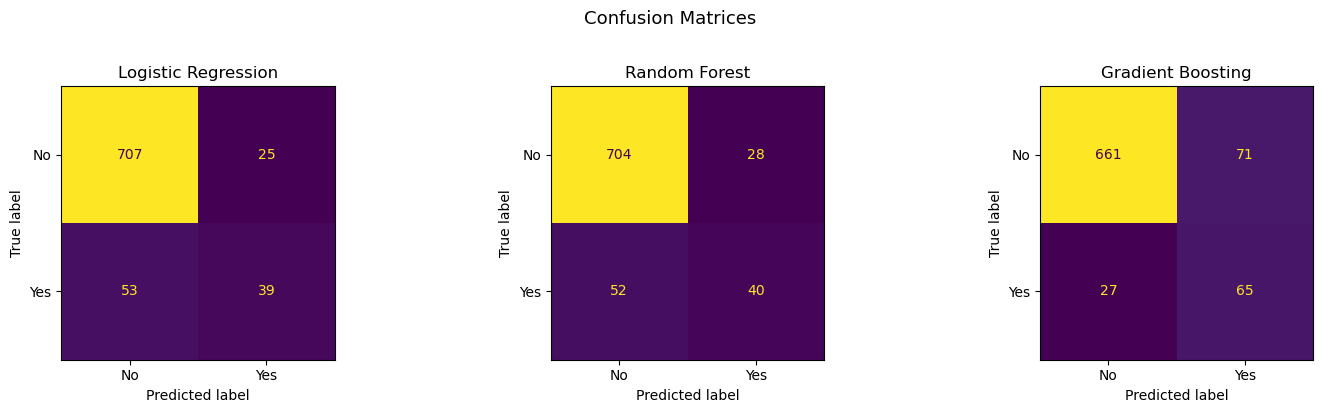

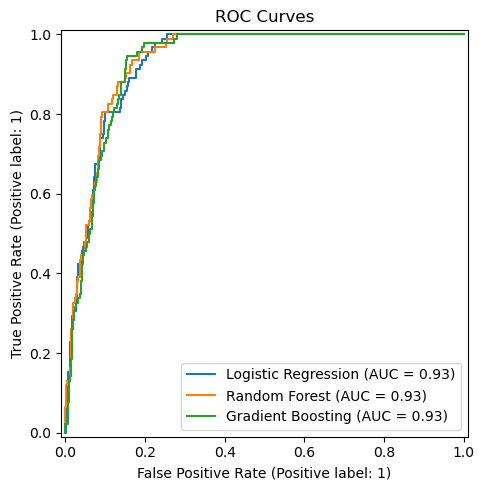

In [20]:
#e)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

#Logistic Regression, baseline (best LR version)
lr_best = LogisticRegression(random_state=42, max_iter=1000)
lr_best.fit(X_train, y_train)

#Random Forest, balanced (best RF version)
rf_best = RandomForestClassifier(n_estimators=300, max_depth=15,
                                  min_samples_split=5, max_features="sqrt",
                                  class_weight="balanced", random_state=42)
rf_best.fit(X_train, y_train)

#Gradient Boosting, balanced weights (best GB version)
gb_best = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                      max_depth=5, subsample=0.8, random_state=42)
sw = compute_sample_weight(class_weight="balanced", y=y_train)
gb_best.fit(X_train, y_train, sample_weight=sw)

#Computing metrics
models = {
    "Logistic Regression": lr_best,
    "Random Forest":       rf_best,
    "Gradient Boosting":   gb_best
}
print("Metrics:")
print(f"{'Model':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9}")


for name, model in models.items():
    preds      = model.predict(X_test)
    proba      = model.predict_proba(X_test)[:, 1]
    accuracy   = accuracy_score(y_test, preds)
    precision  = precision_score(y_test, preds)
    recall     = recall_score(y_test, preds)
    f1         = f1_score(y_test, preds)
    roc_auc    = roc_auc_score(y_test, proba)
    print(f"{name:<25} {accuracy:>9.3f} {precision:>10.3f} {recall:>8.3f} {f1:>8.3f} {roc_auc:>9.3f}")

#Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.suptitle("Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#ROC curves
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title("ROC Curves")
plt.tight_layout()
plt.show()


#Conclusion:
#all three models had overall similar accuracy, but big differences in precision and recall for subscribers
#Gradient Boosting seems to be the best model to use for this task
#this is because it achieved the highest recall and F1 for the subscriber class, correctly identifying 70% of subscribers
#in the context of banking data, the lower precision tradeoff is fine to prioritise capturing subscribers